<a href="https://colab.research.google.com/github/faisu6339-glitch/LLMs/blob/main/Attention_Mechanism(Basic).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Attention Mechanism for English → Hindi Translation

Suppose our input English sentence is:

"I love India"

and we want the model to generate:

"मुझे भारत पसंद है"

The main problem is that while generating each Hindi word, the model needs to know which English words are most relevant at that moment.

That is exactly what attention does.

### 1. Without Attention

Traditional Seq2Seq architecture looks like:

```
English Sentence
      ↓
   Encoder
      ↓
Context Vector
      ↓
   Decoder
      ↓
 Hindi Sentence
```

For example:

```
"I love India"
      ↓
    Encoder
      ↓
 [context vector]
      ↓
    Decoder
      ↓
"मुझे भारत पसंद है"
```

The encoder converts the complete English sentence into a fixed-size representation.

**Problem**

For a long sentence:

"I went to the market yesterday because I wanted to buy some fresh vegetables."

Trying to represent the entire sentence using one context vector can lose important information.

Attention solves this problem.

### 2. With Attention

Instead of forcing the decoder to use only one context vector:

```
English
 ↓
Encoder
 ↓
Hidden States
 ↓
Attention
 ↓
Decoder
 ↓
Hindi
```

The encoder produces a hidden state for each English word.

For:

```
I     love     India
```

we get:

```
h1      h2       h3
↓       ↓        ↓
I      love     India
```

When the decoder generates a Hindi word, attention decides which encoder hidden states are important.

### 3. Example

Input:

`I love India`

Output:

`मुझे भारत पसंद है`

Suppose the decoder is generating:

`भारत`

Attention may give approximately:

```
I       love       India
0.05    0.10       0.85
```

Meaning:

`I       → 5% attention`
`love    → 10% attention`
`India   → 85% attention`

So the model understands:

"I'm currently generating a word related mostly to India."

### 4. Attention During Translation

The decoder generates the Hindi sentence one token at a time.

**Step 1**

Input:

`I love India`

Decoder starts with:

`<START>`

Attention:

```
I       love       India
0.60    0.30       0.10
```

The model might generate:

`मुझे`

**Step 2**

Now decoder has:

`मुझे`

Attention might become:

```
I       love       India
0.20    0.70       0.10
```

The model focuses more on:

`love`

**Step 3**

Decoder:

`मुझे भारत`

Attention:

```
I       love       India
0.05    0.10       0.85
```

Now it focuses strongly on:

`India`

### 5. Attention Scores

Mathematically, we calculate how relevant each encoder hidden state is to the current decoder state.

Let:

Encoder states:

`h1 = representation of "I"`
`h2 = representation of "love"`
`h3 = representation of "India"`

Current decoder state:

`s_t`

We calculate attention scores:

`score(s_t, h1)`
`score(s_t, h2)`
`score(s_t, h3)`

For example:

`score1 = 1.2`
`score2 = 2.8`
`score3 = 4.5`

Higher score means greater relevance.

### 6. Softmax

The raw scores are converted into probabilities using Softmax.

For example:

Scores:

`1.2`
`2.8`
`4.5`

After Softmax:

`0.03`
`0.15`
`0.82`

So:

`I       → 0.03`
`love    → 0.15`
`India   → 0.82`

These are called attention weights.

### 7. Context Vector

Now the model creates a weighted combination of encoder hidden states.

The formula is:

`c`
`t`
`	​`

`=`
`i`
`∑`
`	​`

`α`
`t,i`
`	​`

`h`
`i`
`	​`

where:

`c`
`t`
`	​`

` = context vector`
`α`
`t,i`
`	​`

` = attention weight`
`h`
`i`
`	​`

` = encoder hidden state`

For example:

`Context =`
`0.03 × h1`
`+`
`0.15 × h2`
`+`
`0.82 × h3`

Therefore, the context vector contains mostly information about:

`India`

### 8. Complete Attention Flow

The whole process looks like:

```
              ENGLISH
                 │
        ┌────────┼────────┐
        ↓        ↓        ↓
        I       love     India
        │        │        │
        ↓        ↓        ↓
       h1       h2       h3
        │        │        │
        └────────┼────────┘
                 ↓
          Attention Scores
                 ↓
          Softmax Weights
                 ↓
       0.03   0.15   0.82
                 ↓
          Context Vector
                 ↓
              Decoder
                 ↓
               भारत
```

The decoder repeats this process for every output token.

### 9. Query, Key and Value

This becomes especially important when moving from traditional Seq2Seq attention to Transformers and LLMs.

Attention uses three concepts:

`Query`
`Key`
`Value`

Think of them as:

`Query`

"What information am I looking for?"

`Key`

"What information does each token contain?"

`Value`

"What information should I actually retrieve?"

The basic attention equation is:

`Attention(Q,K,V)=softmax(`
`d`
`k`
`	​`

`	​`

`QK`
`T`
`	​`

`)V`

This is the famous Scaled Dot-Product Attention equation used in Transformers.

### 10. Example with English → Hindi

Suppose the English sentence is:

`I love India`

Each token is converted into embeddings.

`I       → embedding`
`love    → embedding`
`India   → embedding`

From these representations, the Transformer creates:

`Q = Query`
`K = Key`
`V = Value`

Then:

`Q × Kᵀ`

calculates how strongly tokens should interact.

Then:

`QKᵀ / √dk`

scales the scores.

Then:

`Softmax`

converts them into probabilities.

Finally:

`Attention weights × V`

produces the new representation.

### 11. Why Attention Is Powerful for Translation

Consider:

"The boy who was playing football went to his home."

When translating:

`boy`

the model can focus on:

`boy`

When translating:

`football`

it can focus on:

`football`

When translating:

`home`

it can focus on:

`home`

So the model doesn't have to treat the entire sentence equally.

It can dynamically decide:

"Which words are important for what I'm generating right now?"

### 12. Attention vs Self-Attention

This distinction is very important for LLM interviews.

**Attention**

In traditional encoder-decoder translation:

`Decoder → Encoder`

The decoder attends to encoder outputs.

This is generally called cross-attention.

**Self-Attention**

A sequence attends to itself.

For:

`I love India`

the tokens interact with one another:

`I ↔ love`
`I ↔ India`
`love ↔ India`

This helps the model understand relationships between words.

### 13. Transformer Translation Architecture

A simplified Transformer looks like:

```
          English Sentence
                 │
                 ↓
        Token Embeddings
                 │
                 ↓
        Positional Encoding
                 │
                 ↓
        ┌─────────────────┐
        │    Encoder      │
        │                 │
        │ Self-Attention  │
        │       ↓         │
        │ Feed Forward    │
        └────────┬────────┘
                 │
                 ↓
          Encoder Output
                 │
                 ↓
        ┌─────────────────┐
        │    Decoder      │
        │                 │
        │ Masked          │
        │ Self-Attention  │
        │       ↓         │
        │ Cross-Attention │
        │       ↓         │
        │ Feed Forward    │
        └────────┬────────┘
                 │
                 ↓
        Hindi Vocabulary
                 │
                 ↓
      मुझे भारत पसंद है
```

### 14. Self-Attention vs Cross-Attention

| Attention             | What it does                               |
|-----------------------|--------------------------------------------|
| Self-Attention        | Tokens attend to tokens in the same sequence |
| Cross-Attention       | Decoder attends to encoder output          |
| Masked Self-Attention | Prevents decoder from seeing future tokens |

For English → Hindi translation:

```
English Encoder
      ↓
Self-Attention
      ↓
English representation
      ↓
Hindi Decoder
      ↓
Cross-Attention
      ↓
English ↔ Hindi relationship
```

### 15. How LLMs Generate Hindi

Suppose we provide:

`Translate into Hindi:`

`I love India.`

The model may internally generate:

```
<START>
   ↓
मुझे
   ↓
मुझे भारत
   ↓
मुझे भारत पसंद
   ↓
मुझे भारत पसंद है
   ↓
<END>
```

At every generation step, the Transformer calculates attention over the available context.

So conceptually:

```
Input:
I love India

        ↓

Attention

        ↓

Generate "मुझे"

        ↓

Attention again

        ↓

Generate "भारत"

        ↓

Attention again

        ↓

Generate "पसंद"

        ↓

Attention again

        ↓

Generate "है"
```

### 16. One Important Point About Modern LLMs

A modern decoder-only LLM such as a GPT-style model doesn't necessarily use the original encoder-decoder translation architecture.

Instead, it can perform translation using its decoder-only Transformer architecture.

For example:

`Translate English to Hindi:`

`"I love India"`

The model uses:

```
Tokenization
      ↓
Embeddings
      ↓
Positional information
      ↓
Masked Self-Attention
      ↓
Feed Forward Network
      ↓
Next-token prediction
      ↓
Hindi tokens
```

So when you're learning attention for LLMs, focus heavily on:

`Self-Attention`
`Query, Key, Value`
`Scaled Dot-Product Attention`
`Softmax`
`Attention weights`
`Multi-Head Attention`
`Masked/Causal Attention`
`Cross-Attention`
`Transformer architecture`
`Next-token prediction`

### 17. Simple Mental Model

Remember this:

```
English Sentence
       ↓
     Tokens
       ↓
    Embeddings
       ↓
   Q, K, V
       ↓
 Attention Scores
       ↓
    Softmax
       ↓
 Attention Weights
       ↓
 Weighted Values
       ↓
 New Representation
       ↓
 Predict Next Token
       ↓
 Hindi Sentence
```

# 1. Calculate Attention Scores

In [1]:
import numpy as np

query = np.array([1, 2, 3])

keys = np.array([
    [1, 2, 3],
    [2, 1, 2],
    [3, 2, 1]
])

scores = np.dot(keys, query)

print("Attention Scores:")
print(scores)

Attention Scores:
[14 10 10]


# 2. Calculate Context Vector

In [2]:
import numpy as np

values = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
])

attention_weights = np.array([
    0.1,
    0.2,
    0.7
])

context = np.sum(
    attention_weights[:, None] * values,
    axis=0
)

print("Context Vector:")
print(context)

Context Vector:
[4.2 5.2]


#3. Complete Attention Mechanism

Q
↓
K
↓
Scores
↓
Softmax
↓
Weights
↓
V
↓
Context

In [3]:
import numpy as np

Q = np.array([1, 0, 1])

K = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 1, 1]
])

V = np.array([
    [10, 20],
    [30, 40],
    [50, 60]
])

# Step 1: Calculate scores
scores = np.dot(K, Q)

# Step 2: Softmax
exp_scores = np.exp(scores - np.max(scores))
weights = exp_scores / np.sum(exp_scores)

# Step 3: Context vector
context = np.sum(weights[:, None] * V, axis=0)

print("Scores:")
print(scores)

print("\nAttention Weights:")
print(weights)

print("\nContext Vector:")
print(context)

Scores:
[2 0 2]

Attention Weights:
[0.46831053 0.06337894 0.46831053]

Context Vector:
[30. 40.]


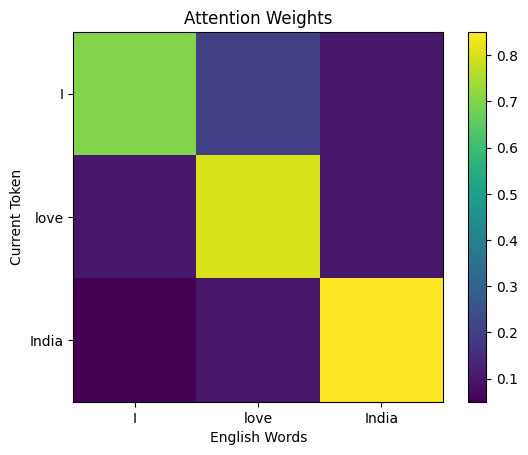

In [4]:
import numpy as np
import matplotlib.pyplot as plt

words = ["I", "love", "India"]

attention = np.array([
    [0.70, 0.20, 0.10],
    [0.10, 0.80, 0.10],
    [0.05, 0.10, 0.85]
])

plt.imshow(attention)

plt.xticks(
    range(len(words)),
    words
)

plt.yticks(
    range(len(words)),
    words
)

plt.xlabel("English Words")
plt.ylabel("Current Token")

plt.title("Attention Weights")

plt.colorbar()

plt.show()